In [1]:
import numpy as np
import pandas as pd
import stumpy
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
df = pd.read_csv('~/Jab/Sensor data/Original Data/2017_OUTPUT_VARS.1h.csv')
df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: '/home/oraja001/Jlab/Sensor data/Original Data/2017_OUTPUT_VARS.1h.csv'

In [3]:
df = df[['DATE', 'IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad43_p1', 'rad29_p1', 'rad48_p2', 'rad43_p2', 'rad29_p2']]
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)
df.head(5)

,IBC1H04CRCUR2,MMSHLAE,BLA,rad48_p1,rad43_p1,rad29_p1,rad48_p2,rad43_p2,rad29_p2
DATE,,,,,,,,,
2017-01-01 00:00:00,0.000008,8518.490234,0.0,0.023,0.013844,0.010447,0.0,0.000366,0.0
2017-01-01 01:00:00,0.000000,8518.490234,0.0,0.023,0.013779,0.010604,0.0,0.000317,0.0
2017-01-01 02:00:00,0.000000,8518.490234,0.0,0.023,0.014689,0.010213,0.0,0.000633,0.0
2017-01-01 03:00:00,0.000017,8518.490234,0.0,0.023,0.014311,0.009708,0.0,0.000449,0.0
2017-01-01 04:00:00,0.000008,8518.490234,0.0,0.023,0.013835,0.009974,0.0,0.000631,0.0


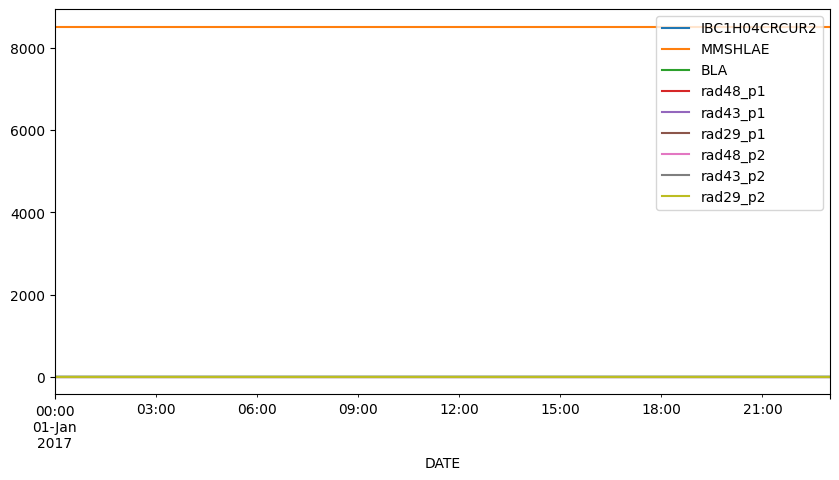

In [4]:
df.loc['2017-01-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad43_p1', 'rad29_p1', 'rad48_p2', 'rad43_p2', 'rad29_p2']].plot(figsize=[10, 5])
plt.legend(loc='upper right')

array([[<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>,
        <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>,
        <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>,
        <Axes: xlabel='DATE'>]], dtype=object)

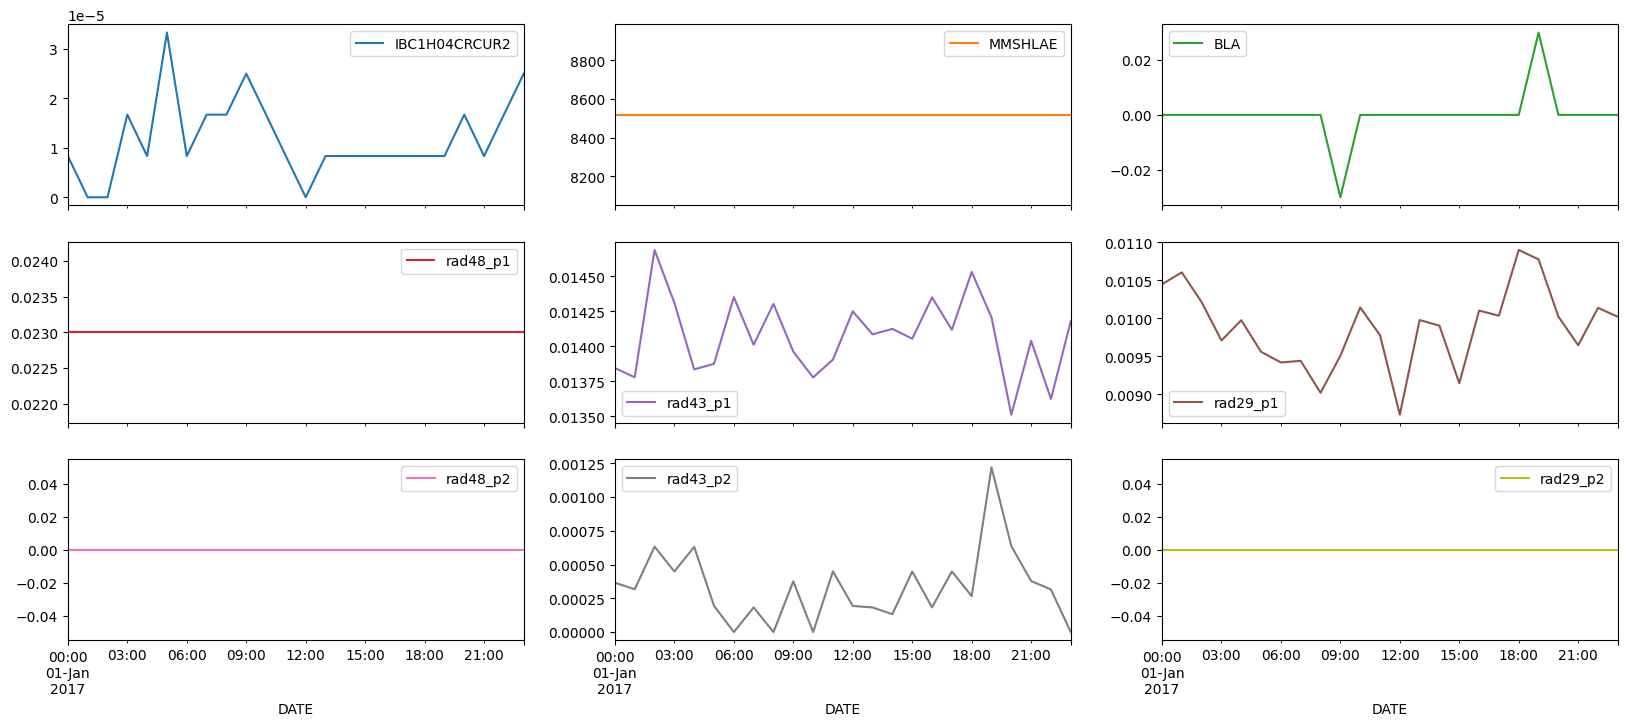

In [5]:
df.loc['2017-01-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad43_p1', 'rad29_p1', 'rad48_p2', 'rad43_p2', 'rad29_p2']].plot(subplots=True, layout=(3, 3), figsize=(20, 8))

In [28]:
# mSTAMP calculates the multivariate matrix profile
m=24 # Window length
mpx, indices = stumpy.mstump(df[['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad43_p1', 'rad29_p1']], m=24)

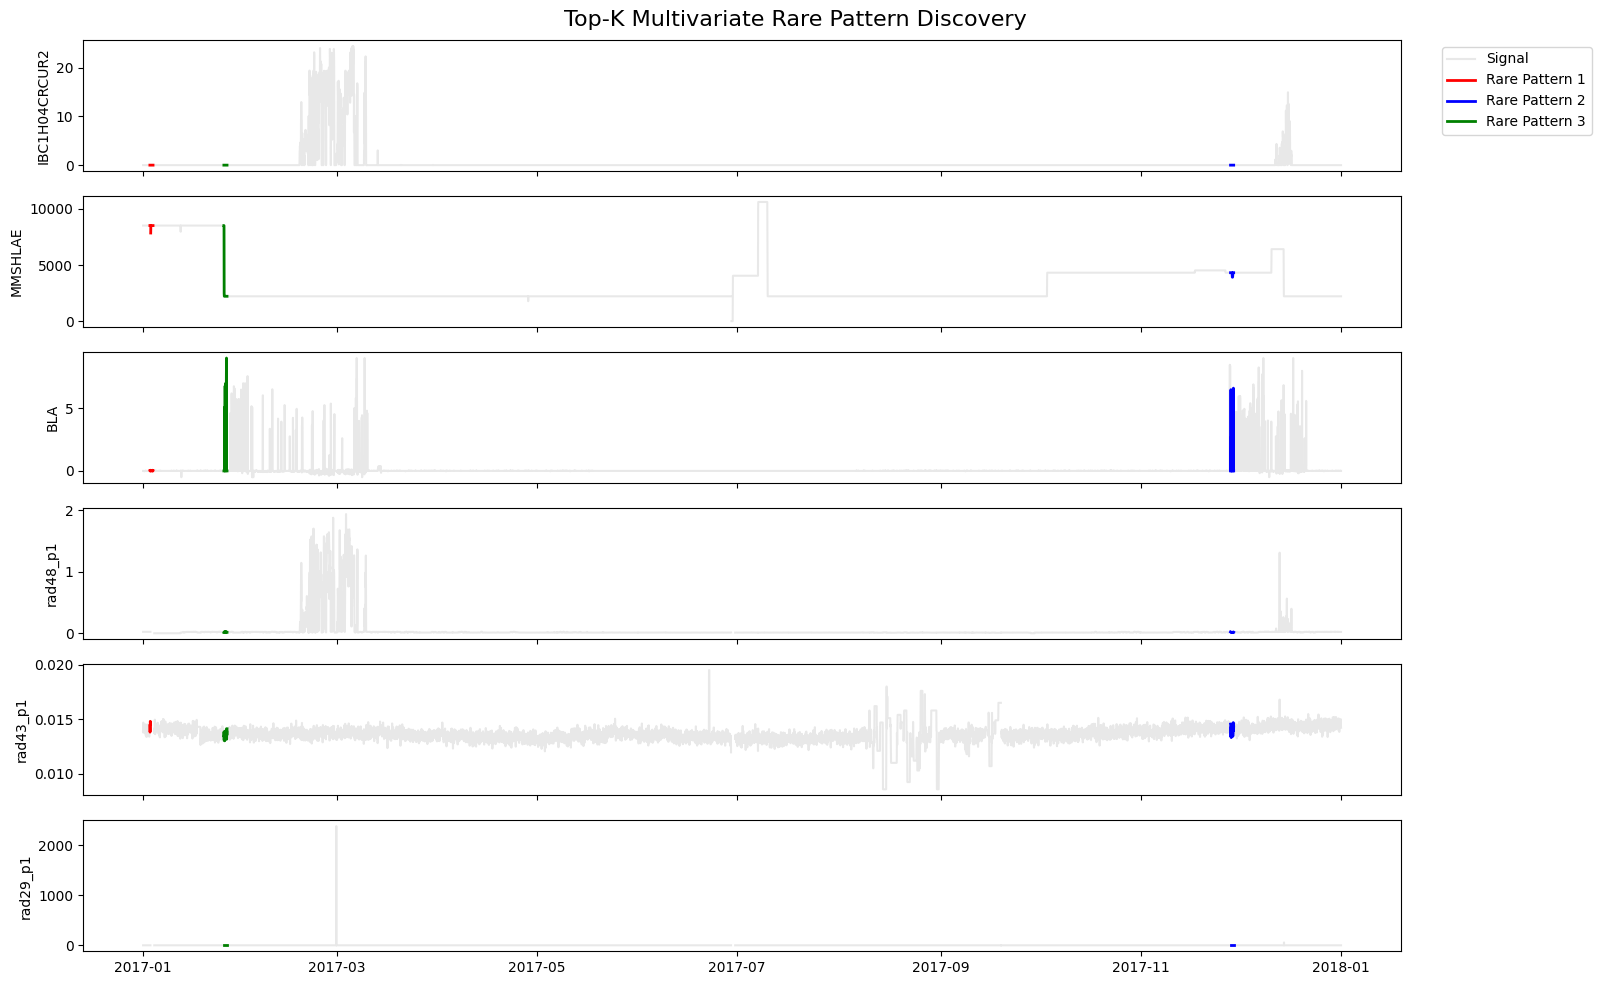

In [29]:
# 1. Identify the Top 3 Rarest Patterns (Discords)
# We use an exclusion zone (m) so we don't pick overlapping windows
k = 3   # Number of patterns to find
mpx_values = mpx[0].copy()
discord_indices = []

for _ in range(k):
    idx = np.argmax(mpx_values)
    discord_indices.append(idx)
    # Mask out the area around this discord so we find a DIFFERENT rare pattern next
    start = max(0, idx - m)
    end = min(len(mpx_values), idx + m)
    mpx_values[start:end] = -1  # Set to low value so it's not picked again

# 2. Plotting the results
fig, axes = plt.subplots(6, 1, figsize=(16, 10), sharex=True)
cols = ['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad43_p1', 'rad29_p1']
colors = ['red', 'blue', 'green'] # One color per rare pattern

for i, col_name in enumerate(cols):
    # Plot the background data
    axes[i].plot(df.index, df[col_name], color='lightgray', alpha=0.5, label='Signal')
    
    # Highlight each of the Top-K discords
    for j, d_idx in enumerate(discord_indices):
        pattern_segment = df.iloc[d_idx : d_idx + m]
        axes[i].plot(pattern_segment.index, pattern_segment[col_name], 
                     color=colors[j], linewidth=2, 
                     label=f'Rare Pattern {j+1}' if i == 0 else "")
    
    axes[i].set_ylabel(col_name)
    if i == 0:
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.suptitle('Top-K Multivariate Rare Pattern Discovery', fontsize=16)
plt.tight_layout()
plt.show()